In [2]:
import os
import pandas as pd
import warnings

# Вимикаємо попередження openpyxl про стилі
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

notebook_dir = os.getcwd()
folder_path = os.path.join(notebook_dir, 'fin_stab_reports')

print(f"Scanning folder: {folder_path}")

if not os.path.exists(folder_path):
    print("ERROR: Folder fin_stab_reports not found.")
else:
    # ШУКАЄМО .xlsx ЗАМІСТЬ .csv
    all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.xlsx')]
    print(f"Found .xlsx files: {len(all_files)}")
    
    if len(all_files) > 0:
        unique_columns = set()

        for file_idx, file in enumerate(all_files):
            print(f"Processing file {file_idx + 1}/{len(all_files)}: {os.path.basename(file)}...")
            try:
                # Читаємо всі вкладки з файлу
                xls = pd.ExcelFile(file)
                for sheet_name in xls.sheet_names:
                    # Пропускаємо технічні вкладки, якщо такі є
                    if sheet_name.lower() in ['spis treści', 'info', 'index']:
                        continue
                    
                    # Читаємо перші 30 рядків вкладки
                    df = pd.read_excel(xls, sheet_name=sheet_name, header=None, nrows=30)
                    
                    for row in df.values:
                        for cell in row:
                            cell_str = str(cell).strip()
                            if cell_str and cell_str.lower() != 'nan':
                                is_number = False
                                try:
                                    float(cell_str.replace(',', '.'))
                                    is_number = True
                                except ValueError:
                                    pass
                                
                                # Фільтрація: не числа, не дати, розумна довжина
                                if not is_number and not cell_str.startswith('20') and 2 < len(cell_str) < 200:
                                    unique_columns.add(cell_str)
            except Exception as e:
                print(f"Failed to read {os.path.basename(file)}: {e}")

        sorted_columns = sorted(list(unique_columns))

        output_file = os.path.join(notebook_dir, 'rsf_nbp_features_from_excel.txt')
        with open(output_file, 'w', encoding='utf-8') as f:
            for col in sorted_columns:
                f.write(col + '\n')

        print(f"\nSuccessfully extracted unique indicators: {len(sorted_columns)}")
        print(f"Saved to: {output_file}")

Scanning folder: /Users/tempdelta/Desktop/ua_pl/fin_stab_reports
Found .xlsx files: 5
Processing file 1/5: rsf122022 (1).xlsx...
Processing file 2/5: 2024.II-Raport-dane (1).xlsx...
Processing file 3/5: 2025.II-Raport-dane-1 (3).xlsx...
Processing file 4/5: Raport-o-stabilnosci-systemu-finansowego.-Grudzien-2023-r.-dane-1 (1).xlsx...
Processing file 5/5: rsf122021 (1).xlsx...

Successfully extracted unique indicators: 2593
Saved to: /Users/tempdelta/Desktop/ua_pl/rsf_nbp_features_from_excel.txt


Starting deep data extraction from NBP reports...
Extraction complete. Building dataset...
Data aligned successfully. Matrix size: (64, 5)


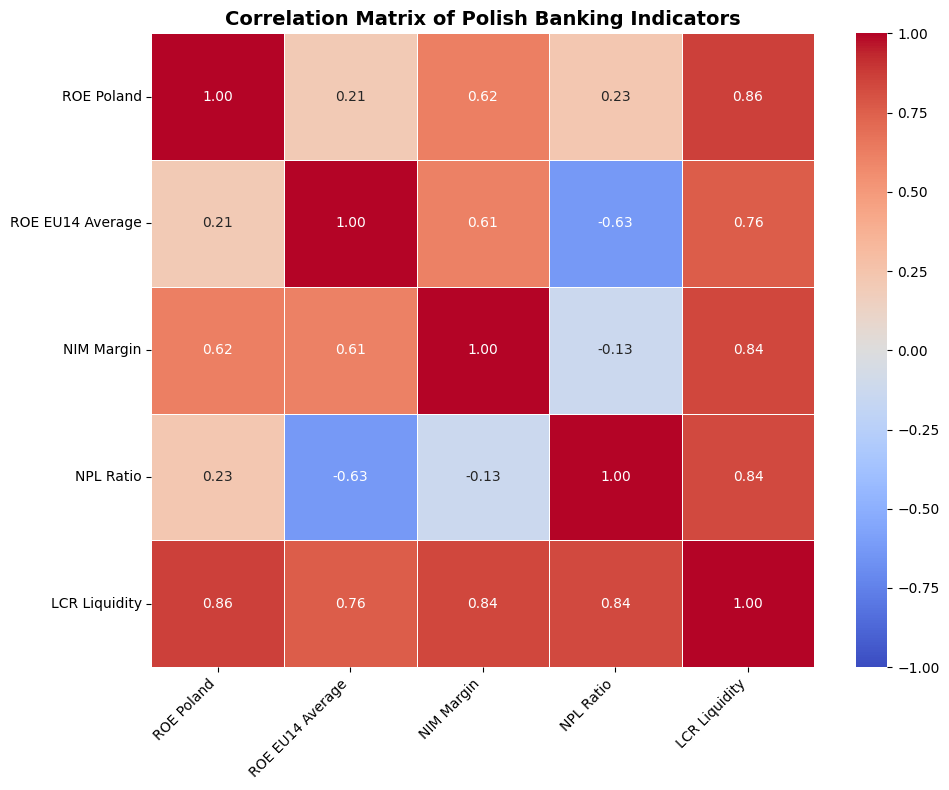

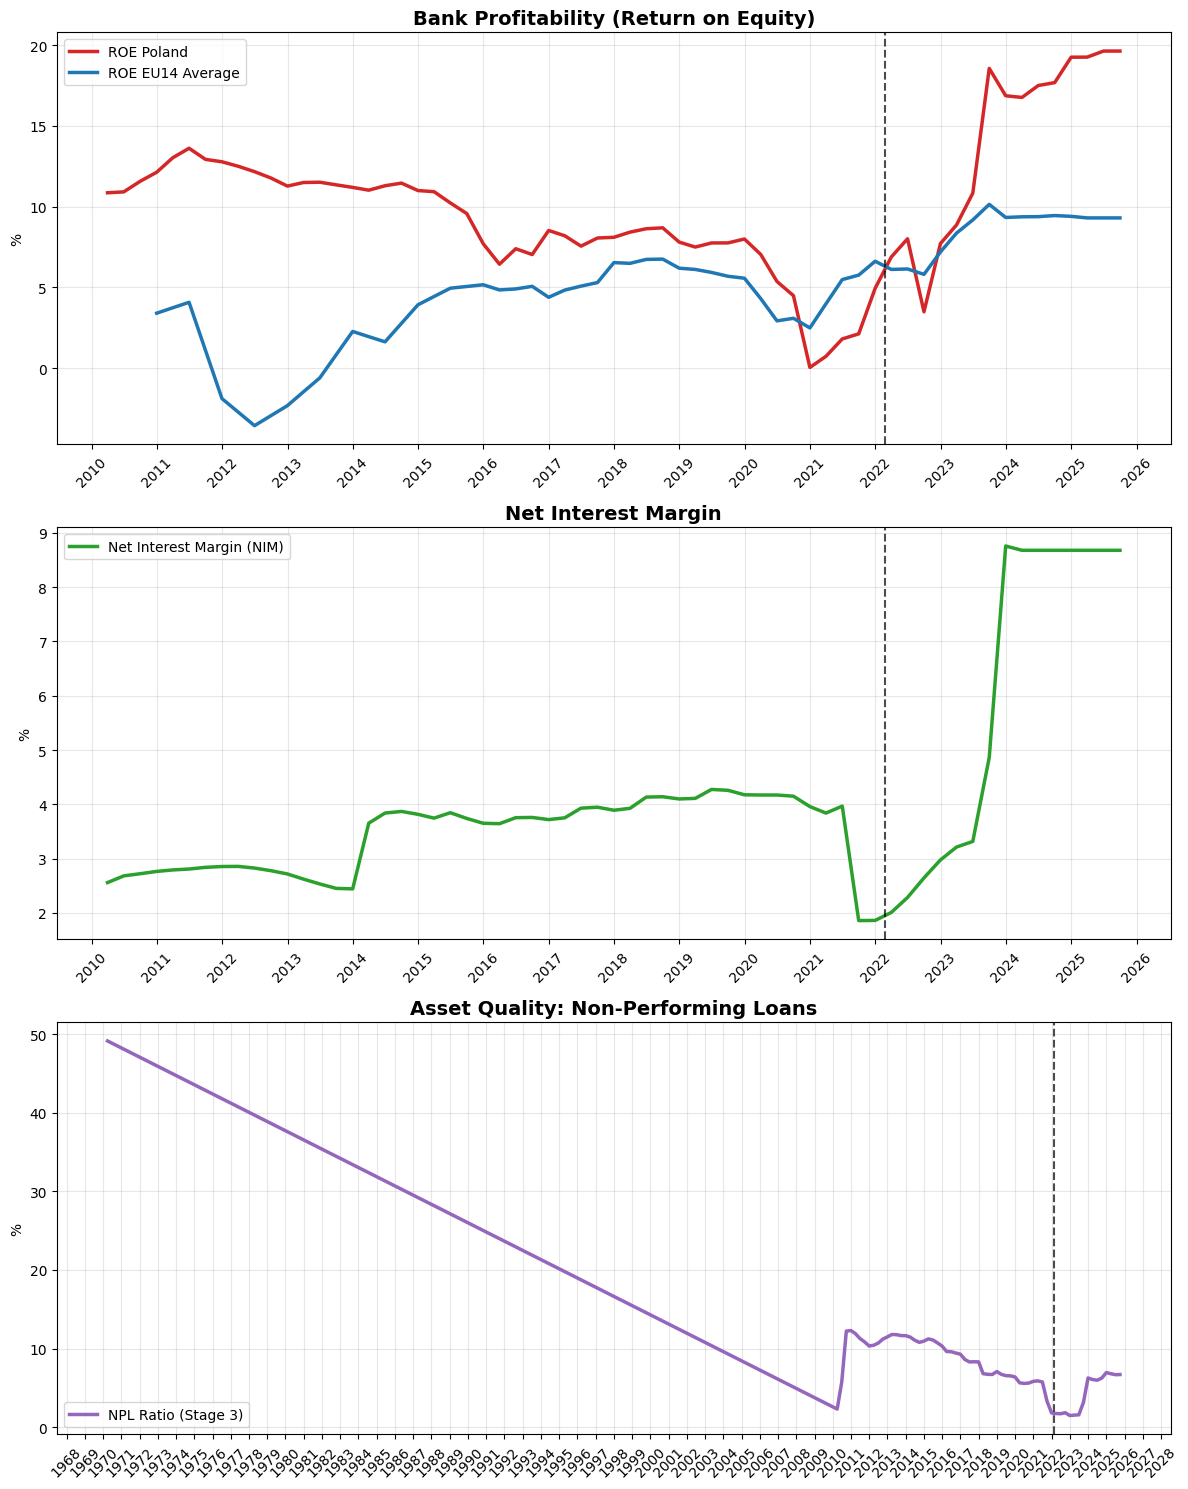

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import matplotlib.dates as mdates

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

notebook_dir = os.getcwd()
folder_path = os.path.join(notebook_dir, 'fin_stab_reports')

# Тільки чисті банківські показники
TARGET_INDICATORS = {
    'ROE_Poland': ['roe'],
    'ROE_EU14_Average': ['eu14'],
    'NIM_Margin': ['nim', 'marża odsetkowa'],
    'NPL_Ratio': ['faza 3', 'zagrożon'],
    'LCR_Liquidity': ['lcr', 'wskaźnik płynności'],
    'Corp_Loans_Growth': ['dynamika kredytów dla przedsiębiorstw'],
    'Retail_Loans_Growth': ['dynamika kredytów dla gospodarstw domowych']
}

master_data = {key: pd.Series(dtype=float) for key in TARGET_INDICATORS.keys()}

print("Starting deep data extraction from NBP reports...")
all_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.xlsx')]

for file in all_files:
    try:
        xls = pd.ExcelFile(file)
        for sheet_name in xls.sheet_names:
            if sheet_name.lower() in ['spis treści', 'info', 'index']:
                continue
                
            df = pd.read_excel(xls, sheet_name=sheet_name, header=None, nrows=50)
            
            date_col_idx = -1
            date_start_row = -1
            for col_idx in range(min(4, len(df.columns))):
                for row_idx in range(min(20, len(df))):
                    val = str(df.iloc[row_idx, col_idx]).strip()
                    if val.startswith('201') or val.startswith('202'):
                        date_col_idx = col_idx
                        date_start_row = row_idx
                        break
                if date_col_idx != -1:
                    break
            
            if date_col_idx == -1:
                continue
                
            super_headers = {}
            for col_idx in range(len(df.columns)):
                header_parts = [str(x) for x in df.iloc[:date_start_row, col_idx].values if str(x).lower() != 'nan']
                super_headers[col_idx] = " ".join(header_parts).lower()
            
            df_full = None
            
            for target_name, keywords in TARGET_INDICATORS.items():
                for col_idx, header_text in super_headers.items():
                    if any(kw in header_text for kw in keywords) and col_idx != date_col_idx:
                        if df_full is None:
                            df_full = pd.read_excel(xls, sheet_name=sheet_name, header=None)
                        
                        raw_dates = df_full.iloc[date_start_row:, date_col_idx]
                        numeric_dates = pd.to_numeric(raw_dates, errors='coerce')

                        # Якщо дата записана як Excel-число (від 30000 до 60000 днів), конвертуємо від 1899 року
                        excel_mask = numeric_dates.notna() & (numeric_dates > 30000) & (numeric_dates < 60000)

                        dates = pd.to_datetime(raw_dates, errors='coerce')
                        dates[excel_mask] = pd.to_datetime(numeric_dates[excel_mask], unit='D', origin='1899-12-30')

                        values = pd.to_numeric(df_full.iloc[date_start_row:, col_idx], errors='coerce')
                        
                        temp_series = pd.Series(values.values, index=dates).dropna()
                        
                        master_data[target_name] = pd.concat([master_data[target_name], temp_series])
                        master_data[target_name] = master_data[target_name][~master_data[target_name].index.duplicated(keep='last')]
                        
    except Exception as e:
        pass 

print("Extraction complete. Building dataset...")

final_df = pd.DataFrame(master_data)
final_df.index = pd.to_datetime(final_df.index, errors='coerce')
final_df = final_df[final_df.index.notna()]
final_df = final_df.sort_index()

# Ресемплінг по кварталах
final_df = final_df.resample('QE').mean().dropna(how='all') 
final_df = final_df.ffill() 

# Відкидаємо пусті колонки
final_df = final_df.dropna(axis=1, how='all')

if final_df.empty or len(final_df.columns) < 2:
    print("Not enough data found to build matrices. Check keyword matching.")
else:
    print(f"Data aligned successfully. Matrix size: {final_df.shape}")

    # ==========================================
    # 0. HEATMAP
    # ==========================================
    plt.figure(figsize=(10, 8))
    corr_matrix = final_df.corr()
    clean_labels = [c.replace('_', ' ') for c in final_df.columns]
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
                linewidths=0.5, annot_kws={"size": 10}, xticklabels=clean_labels, yticklabels=clean_labels)
    plt.title("Correlation Matrix of Polish Banking Indicators", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # LINE CHARTS
    # ==========================================
    available_metrics = []
    if 'ROE_Poland' in final_df.columns: available_metrics.append('ROE')
    if 'NIM_Margin' in final_df.columns: available_metrics.append('NIM')
    if 'NPL_Ratio' in final_df.columns: available_metrics.append('NPL')
    if 'Corp_Loans_Growth' in final_df.columns: available_metrics.append('LOANS')
    
    num_plots = len(available_metrics)
    
    if num_plots > 0:
        fig, axes = plt.subplots(num_plots, 1, figsize=(12, 5 * num_plots), sharex=False)
        if num_plots == 1: axes = [axes]
        
        war_start = pd.to_datetime('2022-02-24')
        plot_idx = 0
        
        # 1. ROE
        if 'ROE' in available_metrics:
            ax = axes[plot_idx]
            ax.plot(final_df.index, final_df['ROE_Poland'] * 100, label='ROE Poland', color='#d62728', linewidth=2.5)
            if 'ROE_EU14_Average' in final_df.columns:
                ax.plot(final_df.index, final_df['ROE_EU14_Average'] * 100, label='ROE EU14 Average', color='#1f77b4', linewidth=2.5)
            ax.set_title('Bank Profitability (Return on Equity)', fontsize=14, fontweight='bold')
            ax.set_ylabel('%')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.axvline(war_start, color='black', linestyle='--', alpha=0.7)
            plot_idx += 1

        # 2. NIM
        if 'NIM' in available_metrics:
            ax = axes[plot_idx]
            nim_data = final_df['NIM_Margin'] * 100 if final_df['NIM_Margin'].mean() < 1 else final_df['NIM_Margin']
            ax.plot(final_df.index, nim_data, label='Net Interest Margin (NIM)', color='#2ca02c', linewidth=2.5)
            ax.set_title('Net Interest Margin', fontsize=14, fontweight='bold')
            ax.set_ylabel('%')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.axvline(war_start, color='black', linestyle='--', alpha=0.7)
            plot_idx += 1

        # 3. NPL
        if 'NPL' in available_metrics:
            ax = axes[plot_idx]
            npl_data = final_df['NPL_Ratio'] * 100 if final_df['NPL_Ratio'].mean() < 1 else final_df['NPL_Ratio']
            ax.plot(final_df.index, npl_data, label='NPL Ratio (Stage 3)', color='#9467bd', linewidth=2.5)
            ax.set_title('Asset Quality: Non-Performing Loans', fontsize=14, fontweight='bold')
            ax.set_ylabel('%')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.axvline(war_start, color='black', linestyle='--', alpha=0.7)
            plot_idx += 1

        # 4. LOANS
        if 'LOANS' in available_metrics:
            ax = axes[plot_idx]
            corp_data = final_df['Corp_Loans_Growth'] * 100 if final_df['Corp_Loans_Growth'].mean() < 1 else final_df['Corp_Loans_Growth']
            ax.plot(final_df.index, corp_data, label='Corporate Loans Growth', color='#ff7f0e', linewidth=2.5)
            if 'Retail_Loans_Growth' in final_df.columns:
                retail_data = final_df['Retail_Loans_Growth'] * 100 if final_df['Retail_Loans_Growth'].mean() < 1 else final_df['Retail_Loans_Growth']
                ax.plot(final_df.index, retail_data, label='Retail Loans Growth', color='#8c564b', linewidth=2.5)
            ax.set_title('Credit Dynamics (YoY Growth)', fontsize=14, fontweight='bold')
            ax.set_ylabel('%')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.axvline(war_start, color='black', linestyle='--', alpha=0.7)
            plot_idx += 1

        # Форматування осей X для всіх графіків
        for ax in axes:
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()